# CDS

This notebook takes VST normalised experimental data, generates characteristic direction (CD) signature for those data, and compares them to existing CDS1000^2 CD signatures.

Signatures are overlayed onto a landmark-gene-only graph structure and passed to a GIN to incorporate structural data into vector representation.

Similarity is assessed by cosine distance between embedding vectors.

python 3.13

# Packages

In [115]:
import itertools
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import pyarrow.parquet as pq
import random
import seaborn as sns
from scipy.stats.mstats import zscore
from sklearn.decomposition import PCA
from tqdm import tqdm as tqdm

# GIN
from sklearn.metrics.pairwise import cosine_similarity
import torch
from torch.nn import Sequential, Identity, Module, Linear
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.utils import from_networkx

# uMAP
import umap.umap_ as umap

# Directories

In [45]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
VST = INPUT + 'vstCounts/'

OUTPUT = 'D:/DDesktop/_work/data/canada/output/'
TABULAR = OUTPUT + 'tabular/'
LOG = OUTPUT + 'log_transformed'
CPM = OUTPUT + 'logCPM_transformed/'

# Functions

In [4]:
def chdir(data, sampleclass, genes, gamma=1., sort=True, calculate_sig=False, nnull=10, sig_only=False, norm_vector=True):
	"""
	Calculate the characteristic direction for a gene expression dataset
	
	Input:
		data: numpy.array, is the data matrix of gene expression where rows correspond to genes and columns correspond to samples
		sampleclass: list or numpy.array, labels of the samples, it has to be consist of 0, 1 and 2, with 0 being columns to be excluded, 1 being control and 2 being perturbation
				example: sampleclass = [1,1,1,2,2,2]
		genes: list or numpy.array, row labels for genes 
		gamma: float, regulaized term. A parameter that smooths the covariance matrix and reduces potential noise in the dataset
		sort: bool, whether to sort the output by the absolute value of chdir
		calculate_sig: bool, whether to calculate the significance of characteristic directions
		nnull: int, number of null characteristic directions to calculate for significance
		sig_only: bool, whether to return only significant genes; active only when calculate_sig is True
		norm_vector: bool, whether to return a characteristic direction vector normalized to unit vector
	Output:
		A list of tuples sorted by the absolute value in descending order characteristic directions of genes.
			If calculate_sig is set to True, each tuple contains a third element which is the ratio of characteristic directions to null ChDir
	"""
	
	## check input
	data.astype(float)
	sampleclass = np.array(list(map(int, sampleclass)))
	# masks
	m_non0 = sampleclass != 0
	m1 = sampleclass[m_non0] == 1
	m2 = sampleclass[m_non0] == 2

	if type(gamma) not in [float, int]:
		raise ValueError("gamma has to be a numeric number")
	if set(sampleclass) != set([1,2]) and set(sampleclass) != set([0,1,2]):
		raise ValueError("sampleclass has to be a list whose elements are in only 0, 1 or 2")
	# if m1.sum()<2 or m2.sum()<2:
	# 	raise ValueError("Too few samples to calculate characteristic directions")
	if len(genes) != data.shape[0]:
		raise ValueError("Number of genes does not match the demension of the expression matrix")

	## normalize data
	data = data[:, m_non0]
	data = zscore(data) # standardize for each genes across samples

	## start to compute
	n1 = m1.sum() # number of controls
	n2 = m2.sum() # number of experiments

	## the difference between experiment mean vector and control mean vector.
	meanvec = data[:,m2].mean(axis=1) - data[:,m1].mean(axis=1) 

	## initialize the pca object
	pca = PCA(n_components=None)
	pca.fit(data.T)

	## compute the number of PCs to keep
	cumsum = pca.explained_variance_ratio_ # explained variance of each PC
	keepPC = len(cumsum[cumsum > 0.001]) # number of PCs to keep

	v = pca.components_[0:keepPC].T # rotated data 
	r = pca.transform(data.T)[:,0:keepPC] # transformed data

	dd = ( np.dot(r[m1].T,r[m1]) + np.dot(r[m2].T,r[m2]) ) / float(n1+n2-2) # covariance
	sigma = np.mean(np.diag(dd)) # the scalar covariance

	shrunkMats = np.linalg.inv(gamma*dd + sigma*(1-gamma)*np.eye(keepPC))

	b = np.dot(v, np.dot(np.dot(v.T, meanvec), shrunkMats))

	if norm_vector:
		b /= np.linalg.norm(b) # normalize b to unit vector

	grouped = zip([abs(item) for item in b],b,genes)
	if sort:
		grouped = sorted(grouped,key=lambda x: x[0], reverse=True)


	if not calculate_sig: # return sorted b and genes.
		res = [(item[1],item[2]) for item in grouped]
		return res
	else: # generate a null distribution of chdirs
		nu = n1 + n2 - 2
		y1 = np.random.multivariate_normal(np.zeros(keepPC), dd, nnull).T * np.sqrt(nu / chi2.rvs(nu,size=nnull))
		y2 = np.random.multivariate_normal(np.zeros(keepPC), dd, nnull).T * np.sqrt(nu / chi2.rvs(nu,size=nnull))
		y = y2 - y1 ## y is the null of v

		nullchdirs = []
		for col in y.T:
			bn = np.dot(np.dot(np.dot(v,shrunkMats), v.T), np.dot(col,v.T))
			bn /= np.linalg.norm(bn)
			bn = bn ** 2
			bn.sort()
			bn = bn[::-1] ## sort in decending order
			nullchdirs.append(bn)

		nullchdirs = np.array(nullchdirs).T
		nullchdirs = nullchdirs.mean(axis=1)
		b_s = b ** 2 
		b_s.sort()
		b_s = b_s[::-1] # sorted b in decending order
		relerr = b_s / nullchdirs ## relative error
		# ratio_to_null
		ratios = np.cumsum(relerr)/np.sum(relerr)- np.linspace(1./len(meanvec),1,len(meanvec))
		res = [(item[1],item[2], ratio) for item, ratio in zip(grouped, ratios)] 
		print('Number of significant genes: %s'%(np.argmax(ratios)+1))
		if sig_only:
			return res[0:np.argmax(ratios)+1]
		else:
			return res

def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

# CANADA Data

In [9]:
# Load graph_cds
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# Get nodelist
list_lm = list(graph_cds.nodes)

In [ ]:
# Define file list
list_files = ['6h_vst_quantile_normalized.csv', '24h_vst_quantile_normalized.csv']
# Define treatment list
list_treatment = ['halo', 'nita', 'paro']

# Initialise dataframe
df_cd = pd.DataFrame({'gene_symbol': list_lm})

# Iterate through files
for file in list_files:

    # Get timepoint
    timepoint = file.split('_')[0]

    # Load data
    df = pd.read_csv(OUTPUT + file, index_col = 0)
    # Filter for landmark genes
    df = df[df.index.isin(list_lm)].copy()

    # Define vehicle column list
    list_vehicle = [column for column in df.columns if 'vehicle' in column]
    # Extract columns
    df_vehicle = df[list_vehicle].copy()
    # Reset index
    df_vehicle.reset_index(inplace = True, names = ['gene_symbol'])

    # Iterate through treatments
    for treatment in tqdm(list_treatment, desc = f'Calculating CD vectors for {file}', total = len(list_treatment)):
        
        # Define treatment column list
        #list_columns = [column for column in df.columns if f'inf_{treatment}' in column]
        list_columns = [column for column in df.columns if f'colo_{treatment}' in column]
        # Extract columns
        df_treatment = df[list_columns]
        # Reset index
        df_treatment.reset_index(inplace = True, names = ['gene_symbol'])

        # Merge w/ vehicle data
        df_input = pd.merge(df_vehicle, df_treatment, how = 'left', on = 'gene_symbol')
        # Set index
        df_input.set_index('gene_symbol', inplace = True)
        
        # Extract row names
        list_genes = list(df_input.index)
        # Run characteristic direction algorithm
        cd = chdir(data = df_input.values, sampleclass = [1,1,1,2,2,2], genes = list_genes)
        # Convert to dataframe
        df_output = pd.DataFrame(cd, columns = ['cd', 'gene_symbol'])
        # Rename columns
        df_output.rename(columns = {'cd' : f'{timepoint}_{treatment}'}, inplace = True)
        # Merge
        df_cd = pd.merge(df_cd, df_output, how = 'left', on = 'gene_symbol')
        
# Set index
df_cd.set_index('gene_symbol', inplace = True)
# Save data
#df_cd
# Show data
df_cd.head()

Calculating CD vectors for 6h_vst_quantile_normalized.csv: 100%|██████████| 3/3 [00:00<00:00, 173.16it/s]
Calculating CD vectors for 24h_vst_quantile_normalized.csv: 100%|██████████| 3/3 [00:00<00:00, 187.33it/s]


,6h_halo,6h_nita,6h_paro,24h_halo,24h_nita,24h_paro
gene_symbol,,,,,,
DUSP3,-0.023929,-0.011824,0.008770,-0.006657,0.008870,0.015775
TMED10,-0.019001,0.022450,0.018116,-0.044503,0.003056,0.008631
BLVRA,-0.008665,0.011156,0.059595,0.000689,-0.027416,0.009088
FAS,-0.019231,0.015436,-0.034114,0.023943,-0.058019,-0.056247
ERBB2,-0.009973,-0.003635,-0.011799,-0.036041,-0.030046,-0.022052


# Context Graphs

In [265]:
# Load graph
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')

# Load document list
#list_documents = file_to_list(INPUT + 'list_documents.txt')

# Define parquet file
pf = pq.ParquetFile(INPUT + 'df_attr.parquet')
# Load document list
list_documents = pf.schema.names
print(len(list_documents))

# Filter list_documents
list_filter = [entry for entry in list_documents if 'HT29' in entry and '6H' in entry]
print(len(list_filter))

# List statins
list_statin = [entry for entry in list_documents if 'statin' in entry and 'HT29' in entry and '6H' in entry and 'poscon' not in entry]

# Get n random entries
num_entries = 10
list_random = random.sample(list_filter, num_entries)
list_random = list_random + list_statin

119156
6079


In [234]:
# Initialise graph list
list_pyg = []

# Iterate through df_cd columns
for column in tqdm(df_cd.columns[0:3], desc = 'Converting experimental data to PyG object(s)', total = len(df_cd.columns)):

    # Extract column data as dictionary
    dict_column = df_cd[column].to_dict()
    
    # Copy graph_cds
    graph_column = graph_cds.copy()

    # Set node attributes
    nx.set_node_attributes(graph_column, dict_column, name = 'x')

    # Get perturbagen name from filename
    perturbagen_name = column.split('_')[1]
    # Get timepoint
    timepoint = column.split('_')[0].upper()

    # Convert to PyG object
    pyg = from_networkx(graph_column)
    pyg.x = pyg.x.float()
    # Add perturbagen name
    pyg.name = f'{perturbagen_name}'
    # Add perturbagen timepoint
    pyg.timepoint = f'{timepoint}'
    # Append to graph list
    list_pyg.append(pyg)

# Iterate through list_random
for entry in tqdm(list_random, desc = 'Converting CDS data to PyG object(s)', total = len(list_random)):
    
    # Get sig ID
    sig_id = entry.split(':')[0]
    # Get cell line
    cell_line = sig_id.split('_')[1]
    # Get timepoint
    timepoint = sig_id.split('_')[2]

    # Get dose
    dose = entry.split(':')[2]

    # Get perturbagen name
    perturbagen_name = entry.split(':')[3]
    if '-666' in perturbagen_name:
        perturbagen_name = entry.split(':')[1]
    
    # Load selected column from parquet as dictionary
    dict_column = pd.read_parquet(INPUT + 'df_attr.parquet', columns = [entry]).to_dict()
    dict_column = dict_column[entry]

    # Copy graph_cds
    graph_columns = graph_cds.copy()

    # Set node attributes
    nx.set_node_attributes(graph_column, dict_column, name = 'x')

    # Convert to PyG object
    pyg = from_networkx(graph_column)
    pyg.x = pyg.x.float()
    # Add perturbagen name
    pyg.name = f'{perturbagen_name}'
    # Add perturbagen timepoint
    pyg.timepoint = f'{timepoint}'
    # Add perturbagen dose
    pyg.dose = f'{dose}'
    # Add cell line
    pyg.cell = f'{cell_line}'
    # Append to graph list
    list_pyg.append(pyg)

Converting CDS data to PyG object(s): 100%|██████████| 516/516 [1:07:27<00:00,  7.84s/it]


# GIN

In [ ]:
# Set desired embedding dimension
EMBED_DIM = 64

# Define GIN encoder using identity GINConvs and fixed projection to d dimensions
class GINEncoder(Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        
        # Project scalar node feature to d-dim before aggregation
        self.initial_proj = Linear(1, embed_dim)  # assuming input is 1-d per node

        # Identity "MLPs" in GINConv — only aggregate neighbors
        mlp1 = Sequential(Identity())
        mlp2 = Sequential(Identity())

        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)

        self.lin = Identity()  # optionally project again later

    def forward(self, x, edge_index):
        if x.dim() == 1:
            x = x.view(-1, 1)  # reshape from [901] → [901, 1]
        x = self.initial_proj(x)  # shape: [n, d]
        x = self.conv1(x, edge_index)
        x = F.relu(x)  # optional
        x = self.conv2(x, edge_index)
        return self.lin(x)  # shape: [n, d] — node-level embeddings

print('Identity-mapping GIN encoder complete')

# Set seed
# torch.manual_seed(40)

# Instantiate model
encoder = GINEncoder()
encoder.eval()

print('Model instantiated')

# Storage for node-level and graph-level embeddings
node_embeddings = []   # list of (n_i × d) tensors
graph_embeddings = []  # list of (1 × d) tensors

with torch.no_grad():
    for graph in tqdm(list_pyg, desc='Generating embeddings', total=len(list_pyg)):
        x = encoder(graph.x, graph.edge_index)  # node-level: [n, d]
        node_embeddings.append(x)  # store full node-level embeddings

        # Create batch vector for global pooling
        batch = torch.zeros(x.size(0), dtype=torch.long)
        graph_emb = global_add_pool(x, batch)  # shape: [1, d]
        graph_embeddings.append(graph_emb)  # retain 1 × d without squeeze

# Convert graph-level embeddings to a matrix (m × d)
graph_embedding_matrix = torch.cat(graph_embeddings, dim=0).numpy()

Identity-mapping GIN encoder complete
Model instantiated


Generating embeddings: 100%|██████████| 519/519 [00:00<00:00, 586.94it/s]


# Cosine Similarity

In [269]:
# Set list_known_ids
list_known_ids = ['halo', 'paro', 'nita']
# Subtract mean vector and center matrix
centered = graph_embedding_matrix - graph_embedding_matrix.mean(axis=0, keepdims=True)
# Normalise centered values
centered_norm = centered / np.linalg.norm(centered, axis=1, keepdims=True)

# Initialise dataframe
df_centered = pd.DataFrame()

# Iterate through IDs
#for pert_name, timepoint in itertools.product(list_known_ids, ['6H', '24H']):
for pert_name, timepoint in itertools.product(list_known_ids, ['6H']):
    # Find index in list_pyg
    ref_idx = next(i for i, g in enumerate(list_pyg) if g.name == pert_name and g.timepoint == timepoint)
    
    # Calculate cosine similarity
    sims = cosine_similarity([centered_norm[ref_idx]], centered_norm)[0]
    # Sort values 
    sims_sort = np.sort(sims)[::-1]
    # Sort by closest similarity
    similarity = sims.argsort()[::-1]
    # Get graph pert_names
    similar_ids = [list_pyg[i].name for i in similarity]
    # Get graph timepoints
    timepoints = [list_pyg[i].timepoint for i in similarity]
    # # Convert to dataframe
    df_id = pd.DataFrame(similar_ids, columns = ['perturbagen_name'])
    # Add timepoint column
    df_id['timepoint'] = timepoints
    # # Merge
    # df_id = pd.merge(df_id, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
    # Add column
    df_id['value'] = sims_sort
    # Add ref column
    df_id['ref_name'] = pert_name
    df_id['ref_timepoint'] = timepoint
    #df_id['ref_name'] = df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == pert_name].values[0]
    # Concatenate
    df_centered = pd.concat([df_centered, df_id])

# Filter data
#df_centered = df_centered[df_centered['timepoint'] == '6H']
# Show data
df_centered.iloc[1:21, :]

,perturbagen_name,timepoint,value,ref_name,ref_timepoint
1,perphenazine,6H,1.0,halo,6H
2,VU0365114-2,6H,1.0,halo,6H
3,N-(1H-indol-5-yl)-2-thiophenecarboxamide,6H,1.0,halo,6H
4,BRD-A98378129,6H,1.0,halo,6H
5,MLS-0315871.0001,6H,1.0,halo,6H
6,Benazepril hydrochloride,6H,1.0,halo,6H
7,STOCK2S-51049,6H,1.0,halo,6H
8,MK 212,6H,1.0,halo,6H
9,itavastatin ca,6H,1.0,halo,6H
10,BRD-A22783572,6H,1.0,halo,6H


In [273]:
# Parameters
EMBED_DIM = 64
NUM_SEEDS = 20
TARGET_ID = 'halo'
TARGET_TIMEPOINT = '6H'
TOP_N = 10

# Define the encoder (same as before)
class GINEncoder(Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.initial_proj = Linear(1, embed_dim)
        mlp1 = Sequential(Identity())
        mlp2 = Sequential(Identity())
        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)
        self.lin = Identity()
    def forward(self, x, edge_index):
        if x.dim() == 1:
            x = x.view(-1, 1)
        x = self.initial_proj(x)
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return self.lin(x)

# Function to generate embeddings given a random seed
def generate_embeddings(seed):
    torch.manual_seed(seed)
    encoder = GINEncoder()
    encoder.eval()
    graph_embeddings = []

    with torch.no_grad():
        for graph in list_pyg:
            x = encoder(graph.x, graph.edge_index)
            batch = torch.zeros(x.size(0), dtype=torch.long)
            graph_emb = global_add_pool(x, batch)
            graph_embeddings.append(graph_emb)
    
    matrix = torch.cat(graph_embeddings, dim=0).numpy()
    return matrix

# Store results per seed
results = []

for seed in tqdm(range(NUM_SEEDS), desc = 'Running seeds', total = NUM_SEEDS):
    #print(f"\n=== Running seed {seed} ===")
    matrix = generate_embeddings(seed)

    # Center and normalize
    centered = matrix - matrix.mean(axis=0, keepdims=True)
    centered_norm = centered / np.linalg.norm(centered, axis=1, keepdims=True)

    # Find reference graph index
    ref_idx = next(i for i, g in enumerate(list_pyg)
                   if g.name == TARGET_ID and g.timepoint == TARGET_TIMEPOINT)

    sims = cosine_similarity([centered_norm[ref_idx]], centered_norm)[0]
    sorted_idx = sims.argsort()[::-1]
    
    top_names = [list_pyg[i].name for i in sorted_idx[:TOP_N]]
    top_scores = sims[sorted_idx[:TOP_N]]

    df = pd.DataFrame({
        'seed': seed,
        'rank': np.arange(1, TOP_N + 1),
        'perturbagen_name': top_names,
        'cosine_sim': top_scores
    })
    results.append(df)

df_results = pd.concat(results, ignore_index=True)
df_results.head()

Running seeds: 100%|██████████| 20/20 [00:13<00:00,  1.48it/s]


,seed,rank,perturbagen_name,cosine_sim
0,0,1,halo,1.000000
1,0,2,2-(4-(tert-butyl)benzamido)-4-chlorobenzoic ac...,0.999999
2,0,3,PROTRYPTYLINE HYDROCHLORIDE,0.999999
3,0,4,STOCK2S-51049,0.999999
4,0,5,BRD-A93236127,0.999999


In [277]:
#df_results['perturbagen_name'].value_counts()
df_grouped = df_results.groupby('perturbagen_name')['rank'].mean().sort_values()
df_grouped

perturbagen_name
halo                                                            1.0
2-(4-(tert-butyl)benzamido)-4-chlorobenzoic acid KUC105998N     2.0
BRD-K25784575                                                   2.0
BRD-K06854232                                                   2.0
perphenazine                                                    2.0
                                                               ... 
L 161982                                                        9.0
BRD-K70330367                                                  10.0
CVF-CSC-7 BRD-A32595718                                        10.0
BRD-A89049230                                                  10.0
BRD-K70161581                                                  10.0
Name: rank, Length: 80, dtype: float64

In [262]:
for drug in list_known_ids:
    # df_slice = df_centered[(df_centered['ref_name'] == drug) &
    #                        (df_centered['timepoint'] == '6H')]
    df_slice = df_centered[df_centered['ref_name'] == drug]

df_slice.iloc[1:11,:]

,perturbagen_name,timepoint,value,ref_name,ref_timepoint
1,paro,6H,0.999998,nita,6H
2,4-Demethoxydaunorubicin hydrochloride (65),6H,0.999987,nita,6H
3,floxuridine,6H,0.999884,nita,6H
4,EI-293,6H,0.999876,nita,6H
5,BRD-A36630025,6H,0.999876,nita,6H
6,BRD-U00779237,6H,0.999871,nita,6H
7,F3055,6H,0.999871,nita,6H
8,N-((5-chloro-1H-benzo[d]imidazol-2-yl)methyl)-...,6H,0.999864,nita,6H
9,DAUNORUBICIN,6H,0.999864,nita,6H
10,BRD-A30437061,6H,0.999862,nita,6H


# uMAP

In [263]:
# uMAP
reducer = umap.UMAP(n_components=2, random_state=42, spread = 1)
embedding_2d = reducer.fit_transform(centered_norm)
graph_ids = [g.name for g in list_pyg]
graph_timepoints = [g.timepoint for g in list_pyg]

# Convert to dataframe
df_plot = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_plot['perturbagen_name'] = graph_ids
df_plot['timepoint'] = graph_timepoints

# Filter data
# df_plot = df_plot[(df_plot['timepoint'] == '6H') |
#                   (df_plot['timepoint'] == '24H')]
df_plot = df_plot[df_plot['timepoint'] == '6H']

# Show data
df_plot.head()

c:\Users\roman\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,x,y,perturbagen_name,timepoint
0,2.466610,5.886741,halo,6H
1,-15.002263,12.870740,nita,6H
2,-14.975760,12.875010,paro,6H
3,-12.477499,12.535234,BRD-U88861852,6H
4,2.967164,5.705540,BRD-K00541156,6H


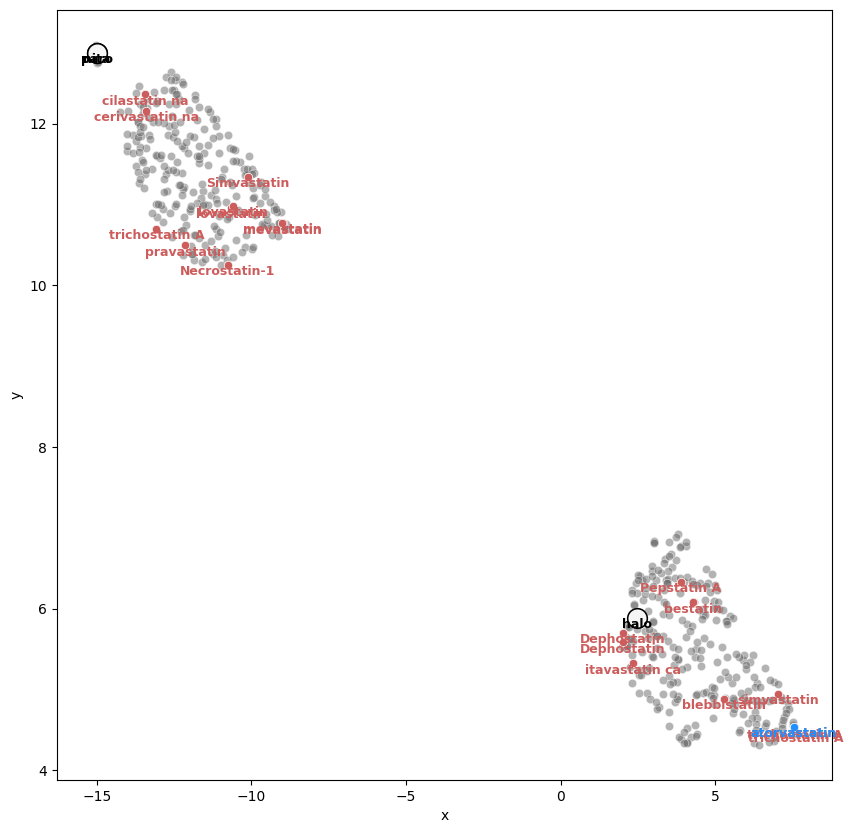

In [264]:
plt.figure(figsize = (10,10))
sns.scatterplot(df_plot, x = 'x', y = 'y', c = 'dimgrey', alpha = 0.5)

subset = df_plot[df_plot['perturbagen_name'].isin(list_known_ids)]
statins = df_plot[df_plot['perturbagen_name'].str.contains('statin')]
ator = df_plot[df_plot['perturbagen_name'].str.contains('atorvastatin')]
sns.scatterplot(statins, x = 'x', y = 'y', c = 'indianred')
sns.scatterplot(ator, x = 'x', y = 'y', c = 'dodgerblue')
sns.scatterplot(subset, x = 'x', y = 'y', s = 200, c = 'whitesmoke', edgecolor = 'black', legend = None, label = 'perturbagen_name')


# Add text labels for each highlighted point
for _, row in subset.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='black'
    )

# Add text labels for each highlighted point
for _, row in statins.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='indianred'
    )

# Add text labels for each highlighted point
for _, row in ator.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='dodgerblue'
    )